In [1]:
#%%
import cellpose.core
import time, os, sys
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
mpl.rcParams['figure.dpi'] = 300
from cellpose import utils, io
from cellpose import models, io
import cellpose
import pandas as pd
import numpy as np
from skimage.io import imread
import scipy as sp
from cellpose import plot
from scipy.signal import savgol_filter
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from skimage.segmentation import find_boundaries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, matthews_corrcoef
import matplotlib.patches as patches

import imageio
plt.rcParams["figure.figsize"] = (3,3)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline



In [2]:
cellpose.core.use_gpu()

True

In [3]:
pwd

'/n/home01/pnandabbs/DCS/Manuscript/Figure3/Figure3B_mtsfGFP'

In [4]:
data_directory='/n/boslfs02/LABS/murray_lab/Users/pnanda/DCS/Manuscript/eDCS031_mtsfGFP_mNept_687/'
save_directory='/n/home01/pnandabbs/DCS/Manuscript/Figure3/Figure3B_mtsfGFP/Masks/'

In [5]:
model = models.CellposeModel(gpu=True, model_type='cyto2')
chan = [[0,0]]

model_type argument is not used in v4.0.1+. Ignoring this argument...


In [6]:
files=os.listdir(data_directory)

In [7]:
# s=12

# img_stack=[]

# for i in range(1,37,1):
#     file_loc=data_directory+"yPN_w1Brightfield confocal_s"+str(s)+"_t"+str(i)+".TIF"
#     img_stack.append(imread(file_loc).astype('int16'))

# file=np.stack(img_stack)
# mask_loc=save_directory+str(s)+"masks.npy"
# np.save(mask_loc,file)
    


In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

cmap_red   = LinearSegmentedColormap.from_list("black_red",   ["black", "red"])
cmap_green = LinearSegmentedColormap.from_list("black_green", ["black", "lime"])  # or "green"


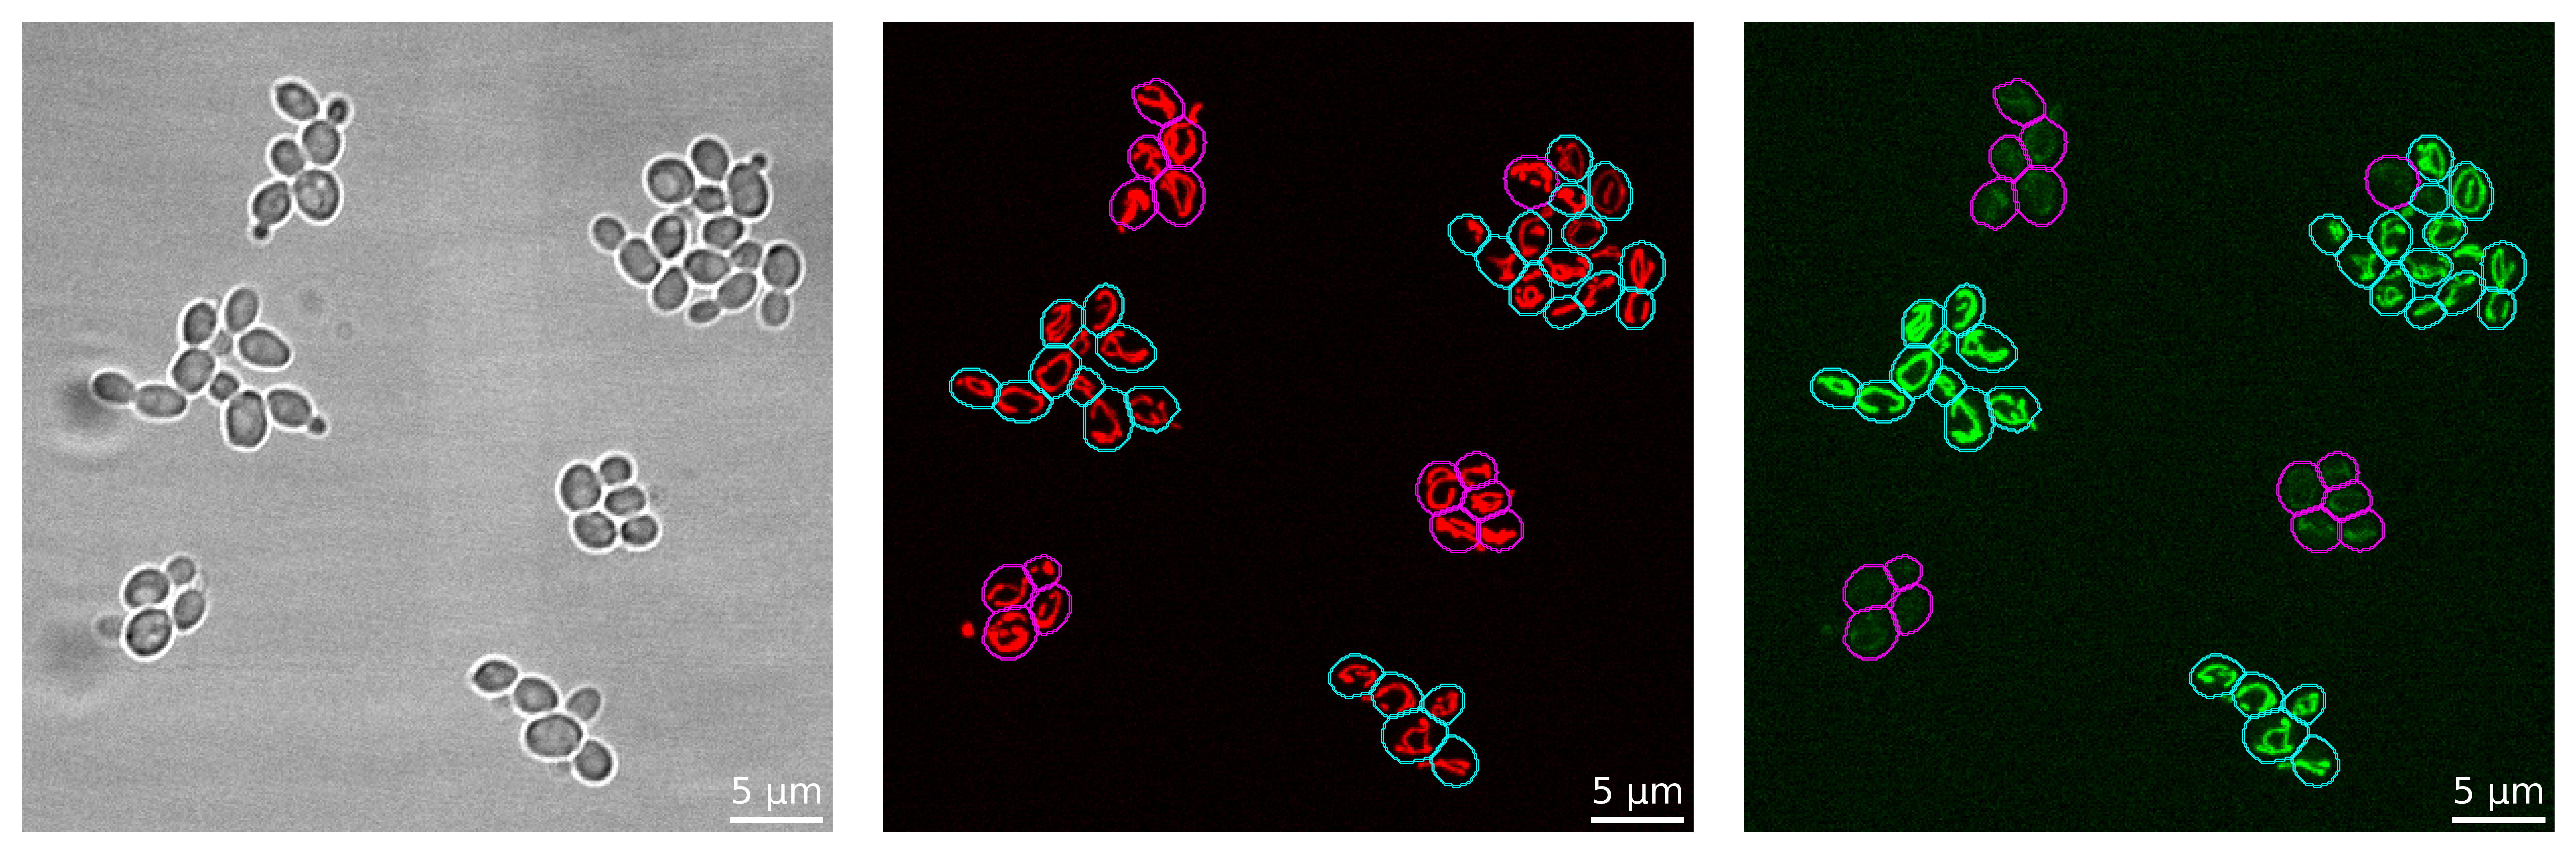

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.segmentation import find_boundaries
import matplotlib.patches as patches
import pandas as pd

# --------------------------------------------------
# Params
# --------------------------------------------------
s = 12
t = 6

st1 = 20
en1 = 420
st2 = 60
en2 = 460

# --------------------------------------------------
# Load stacks (crop)
# --------------------------------------------------
img_stack_mcherry = imread(
    data_directory + f"yPN_w3594 laser 20_s{s}_t{t}.TIF"
).astype("int16")[:, st1:en1, st2:en2]

img_stack_yfp = imread(
    data_directory + f"yPN_w2488 laser 25r_s{s}_t{t}.TIF"
).astype("int16")[:, st1:en1, st2:en2]

img_stack = imread(
    data_directory + f"yPN_w1Brightfield confocal_s{s}_t{t}.TIF"
).astype("int16")[:, st1:en1, st2:en2]

# --------------------------------------------------
# Load 2D labels.tif for this field
# --------------------------------------------------
labels_full = imread(f"Labels{s}.tif").astype("int16")
labels = labels_full[5, 4, st1:en1, st2:en2]   # shape (H, W)

# --------------------------------------------------
# Segmentation (Cellpose) on BF slice
# --------------------------------------------------
bf = img_stack[4]
masks_zero, flows, diams = model.eval(bf, diameter=5)
masks = masks_zero

# --------------------------------------------------
# Build per-mask label from labels.tif
# --------------------------------------------------
mask_ids = np.unique(masks)
mask_ids = mask_ids[mask_ids != 0]

rows = []
for mid in mask_ids:
    m = (masks == mid)
    labs, counts = np.unique(labels[m], return_counts=True)
    labs_nz = labs[labs != 0]
    if len(labs_nz) == 0:
        maj_lab = 0
    else:
        counts_nz = counts[labs != 0]
        maj_lab = labs_nz[np.argmax(counts_nz)]
    rows.append((mid, maj_lab))

df = pd.DataFrame(rows, columns=['mask_id', 'label'])

# --------------------------------------------------
# Projections and clipping
# --------------------------------------------------
mch = img_stack_mcherry.max(axis=0)
yfp = img_stack_yfp.max(axis=0)

def pclip(im, lo=20, hi=99):
    vmin, vmax = np.percentile(im, (lo, hi))
    return vmin, vmax

bf_min,  bf_max  = pclip(bf,  lo=0,  hi=99)
mch_min, mch_max = pclip(mch, lo=10, hi=99)
yfp_min, yfp_max = pclip(yfp, lo=1, hi=99.5)

# --------------------------------------------------
# Per-mask label → color mapping (only annotated classes)
# --------------------------------------------------
label_to_color = {
    1: 'magenta',
    2: 'cyan',
}

mask_to_label = dict(zip(df['mask_id'].values, df['label'].values))
mask_to_color = {
    mid: label_to_color[lab]
    for mid, lab in mask_to_label.items()
    if lab in label_to_color
}

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(12, 4), dpi=600)

ax[0].imshow(bf,  cmap="gray",     vmin=bf_min,  vmax=bf_max)
ax[1].imshow(mch, cmap=cmap_red,   vmin=mch_min, vmax=mch_max)
ax[2].imshow(yfp, cmap=cmap_green, vmin=yfp_min, vmax=yfp_max)

# --------------------------------------------------
# Thin solid boundaries (per mask, colored)
# --------------------------------------------------
for mid, col in mask_to_color.items():
    m = (masks == mid)
    if not m.any():
        continue
    bnd = find_boundaries(m, mode='outer')

    # contour draws a thin, continuous line
    ax[1].contour(
        bnd.astype(float),
        levels=[0.5],
        colors=[col],
        linewidths=0.4
    )
    ax[2].contour(
        bnd.astype(float),
        levels=[0.5],
        colors=[col],
        linewidths=0.4
    )

# --------------------------------------------------
# Scale bar
# --------------------------------------------------
pixel_size_um = 0.108
scalebar_um   = 5
scalebar_px   = int(scalebar_um / pixel_size_um)

def add_scalebar(ax, length_px, label=None,
                 color='white', height_px=3, pad_px=5):
    img = ax.images[0]
    h, w = img.get_array().shape

    x0 = w - length_px - pad_px
    y0 = h - height_px - pad_px

    rect = patches.Rectangle((x0, y0),
                             length_px, height_px,
                             linewidth=3,
                             edgecolor=None,
                             facecolor=color)
    ax.add_patch(rect)

    if label is not None:
        ax.text(x0 + length_px/2,
                y0 - 3,
                label,
                color=color,
                ha='center', va='bottom',
                fontsize=12)

for a in ax:
    a.axis("off")
    add_scalebar(a, scalebar_px, label=f'{scalebar_um} µm')

fig.tight_layout(pad=1)

# Vector version (best for journals)
fig.savefig(
    "mtsfGFP_final_w_boundaries.pdf",
    dpi=1200,
    bbox_inches="tight",
    pad_inches=0,
)

# High-DPI raster version
# fig.savefig(
#     "mtsfGFP_final_w_boundaries.png",
#     dpi=1200,            # you can push to 800–1200 if needed
#     bbox_inches="tight",
#     pad_inches=0,
# )


In [10]:
arr_vals=[]
rec_vals=[]

for s in [9,10,12,15]:

    t=6

    img_stack=[]


    file_loc=data_directory+"yPN_w1Brightfield confocal_s"+str(s)+"_t"+str(t)+".TIF"
    img_stack=imread(file_loc).astype('int16')

    file = np.stack(img_stack)

    num_cells=[]
    masks=[]

    masks_zero, flows, diams = model.eval(file[4], diameter=50)
    num_cells.append(masks_zero.max())
    masks.append(masks_zero)

    masks_arr=np.array(masks)



    labels=imread(save_directory+'Labels'+str(s)+'.tif')[6,3,:,:]

    img_stack_mcherry=[]
    img_stack_yfp=[]

    file_loc_mcherry=data_directory+"yPN_w3594 laser 20_s"+str(s)+"_t"+str(t)+".TIF"
    img_stack_mcherry=imread(file_loc_mcherry).astype('int16')


    file_loc_yfp=data_directory+"yPN_w2488 laser 25r_s"+str(s)+"_t"+str(t)+".TIF"
    img_stack_yfp=imread(file_loc_yfp).astype('int16')

    ratio=img_stack_yfp[:].sum(axis=0)

    masks = masks_arr[0]

    # Get coordinates where labels exist (non-zero)
    label_coords = np.where(labels > 0)
    label_values = labels[label_coords]

    # For each label pixel, find which mask it belongs to
    mask_values_at_labels = masks[label_coords]

    # Create mapping
    df = pd.DataFrame({
        'mask_id': mask_values_at_labels,
        'label': label_values
    })

    # Remove background masks (mask_id == 0)
    df = df[df['mask_id'] > 0]

    # Get one label per mask (most common)
    df = df.groupby('mask_id')['label'].agg(lambda x: x.mode()[0]).reset_index()

    gfp_vals=[]
    for m in df['mask_id']:
        gfp_vals.append(ratio[masks==m].mean()-ratio[masks==0].mean())

    df['Mean_GFP']=gfp_vals
    
    arr_vals.extend(df.loc[df['label']==2,'Mean_GFP'].tolist())
    rec_vals.extend(df.loc[df['label']==1,'Mean_GFP'].tolist())
    
    
full=arr_vals+rec_vals

rec_vals=np.array(rec_vals)[~np.isnan(rec_vals)]
arr_vals=np.array(arr_vals)[~np.isnan(arr_vals)]

print("Arr mean",np.nanmean(arr_vals))
print("Rec mean",np.nanmean(rec_vals))

print("Arr mean",np.nanstd(arr_vals))
print("Rec mean",np.nanstd(rec_vals))

Arr mean 58.82954806564282
Rec mean 160.00398218030475
Arr mean 14.547041181214217
Rec mean 36.79351699265698


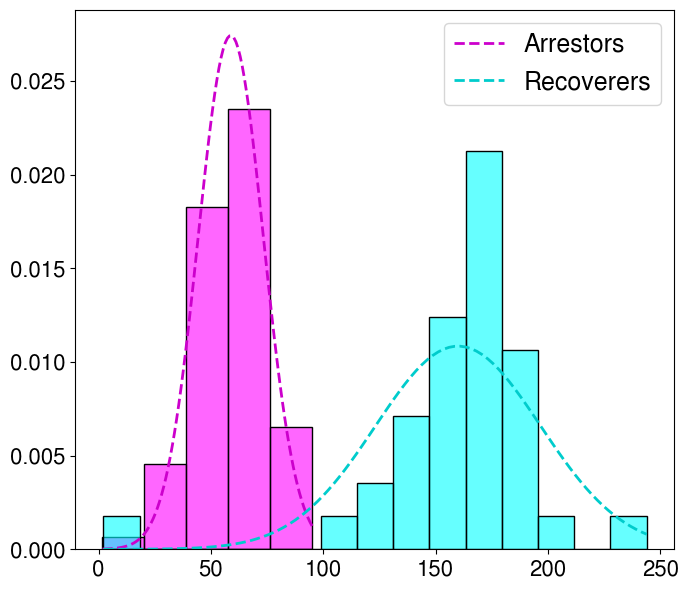

In [11]:
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Fit distributions
mu_arr, std_arr = stats.norm.fit(arr_vals)
mu_rec, std_rec = stats.norm.fit(rec_vals)

# X ranges
x_arr = np.linspace(np.min(arr_vals), np.max(arr_vals), 100)
x_rec = np.linspace(np.min(rec_vals), np.max(rec_vals), 100)

plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.figure(figsize=(7, 6))

# Arrestors = magenta
sns.histplot(
    arr_vals, bins=5, stat="density",
    alpha=0.6, color="#ff00ff"  # magenta
)
plt.plot(
    x_arr, stats.norm.pdf(x_arr, mu_arr, std_arr),
    '--', linewidth=2, color="#cc00cc"
)

# Recoverers = cyan
sns.histplot(
    rec_vals, bins=15, stat="density",
    alpha=0.6, color="#00ffff"  # cyan
)
plt.plot(
    x_rec, stats.norm.pdf(x_rec, mu_rec, std_rec),
    '--', linewidth=2, color="#00cccc"
)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.xlabel(r'sfGFP$^{mt}$ Fluorescence', fontsize=18)
plt.ylabel('', fontsize=18)
plt.legend(['Arrestors', 'Recoverers'], fontsize=18)
plt.tight_layout()
plt.savefig(save_directory + 'mtsfGFP_distribution.png', dpi=1200)


F1: 0.9705882352941176
MCC: 0.9593790508789037


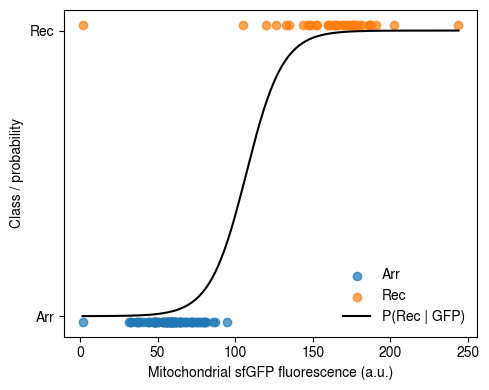

In [12]:
X = np.concatenate([arr_vals, rec_vals])[:, None]   # shape (n_samples, 1)
y = np.concatenate([
    np.zeros(arr_vals.shape[0], dtype=int),
    np.ones(rec_vals.shape[0], dtype=int)
])  # shape (n_samples,)

clf = LogisticRegression(max_iter=1000, solver='lbfgs')
clf.fit(X, y)

y_pred = clf.predict(X)

f1 = f1_score(y, y_pred)
mcc = matthews_corrcoef(y, y_pred)

print("F1:", f1)
print("MCC:", mcc)

x_grid = np.linspace(X.min(), X.max(), 500)[:, None]
p_grid = clf.predict_proba(x_grid)[:, 1]  # P(recovering | GFP)

plt.figure(figsize=(5, 4))

# real points, jittered vertically for visibility
plt.scatter(arr_vals, np.zeros_like(arr_vals) - 0.02,
            color='tab:blue', label='Arr', alpha=0.7)
plt.scatter(rec_vals, np.ones_like(rec_vals) + 0.02,
            color='tab:orange', label='Rec', alpha=0.7)

# logistic regression probability curve
plt.plot(x_grid.ravel(), p_grid, color='k', label='P(Rec | GFP)')

plt.yticks([0, 1], ['Arr', 'Rec'])
plt.xlabel(r"Mitochondrial sfGFP fluorescence (a.u.)")
plt.ylabel('Class / probability')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(save_directory + "sfgfp_logistic.png", dpi=300, bbox_inches="tight")


/tmp/ipykernel_761898/2537686404.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_761898/2537686404.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_761898/2537686404.py:83: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


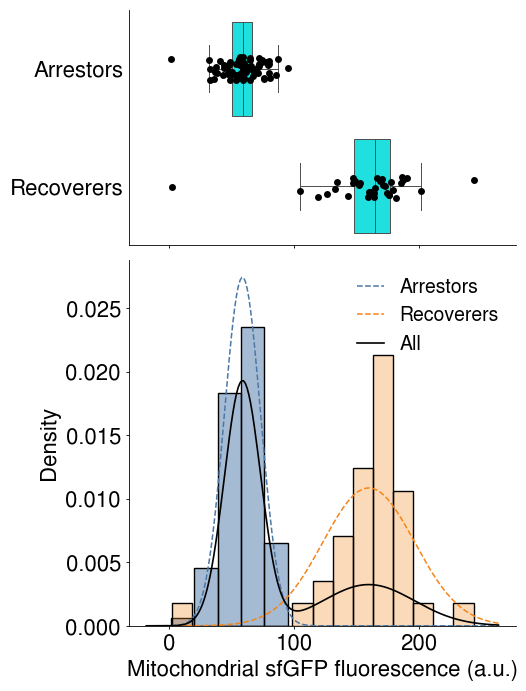

In [13]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Fit Gaussians ----------------
mu_arr, std_arr = stats.norm.fit(arr_vals)
mu_rec, std_rec = stats.norm.fit(rec_vals)

w_arr = len(arr_vals) / (len(arr_vals) + len(rec_vals))
w_rec = 1 - w_arr

x = np.linspace(min(arr_vals.min(), rec_vals.min()) - 20,
                max(arr_vals.max(), rec_vals.max()) + 20, 200)

pdf_arr = stats.norm.pdf(x, mu_arr, std_arr)
pdf_rec = stats.norm.pdf(x, mu_rec, std_rec)
pdf_mix = w_arr * pdf_arr + w_rec * pdf_rec

# ---------------- Aesthetics ----------------
plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 0.6

arr_color = "#4C78A8"   # blue
rec_color = "#F58518"   # orange

# ---------------- Data frame ----------------
df_long = pd.DataFrame({
    "sfGFPmt": np.concatenate([arr_vals, rec_vals]),
    "State": (["Arrestors"] * len(arr_vals)) + (["Recoverers"] * len(rec_vals)),
})

bins_arr = np.histogram_bin_edges(arr_vals, bins=5)
bins_rec = np.histogram_bin_edges(rec_vals, bins=15)

# ---------------- Figure ----------------
fig = plt.figure(figsize=(5.0, 8.0), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[0.9, 1.4], hspace=0.05)

# Top: box + strip
ax_box = fig.add_subplot(gs[0, 0])
sns.boxplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, showfliers=False,
    palette=['cyan', 'cyan'],
    linewidth=0.7
)
sns.stripplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, color="k", size=5, alpha=1
)
ax_box.set_xlabel("")
ax_box.set_ylabel("")
ax_box.tick_params(axis="x", labelbottom=False, length=2, width=0.6)
ax_box.tick_params(axis="y", length=0, width=0.6)

# Bottom: hist + PDFs + mixture
ax_dist = fig.add_subplot(gs[1, 0], sharex=ax_box)

sns.histplot(
    arr_vals, bins=bins_arr, stat="density",
    color=arr_color, alpha=0.5, edgecolor="k", ax=ax_dist
)
sns.histplot(
    rec_vals, bins=bins_rec, stat="density",
    color=rec_color, alpha=0.3, edgecolor="k", ax=ax_dist
)

ax_dist.plot(x, pdf_arr, "--", linewidth=1.1, color=arr_color, label="Arrestors")
ax_dist.plot(x, pdf_rec, "--", linewidth=1.1, color=rec_color, label="Recoverers")
ax_dist.plot(x, pdf_mix, "-",  linewidth=1.2, color="k",        label="All")

ax_dist.set_xlabel(r"Mitochondrial sfGFP fluorescence (a.u.)")
ax_dist.set_ylabel("Density")
ax_dist.tick_params(length=2, width=0.6)
ax_dist.legend(frameon=False, fontsize=14, handlelength=1.4)

sns.despine(fig)
plt.tight_layout()

# High‑res, vector‑friendly save (adjust path as needed)
# fig.savefig(save_directory + "mtsfGFP_box_hist_mixture.pdf")
fig.savefig(save_directory + "sfgfp_box_hist_mixture_d005.png", dpi=300, bbox_inches="tight")


In [14]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.segmentation import find_boundaries
import imageio.v2 as imageio

# --------------------------------------------------
# Params
# --------------------------------------------------
s = 12
t_values = range(1, 30, 5)   # adjust if needed

# --------------------------------------------------
# Crop: x = 50:400, y = 100:300
# --------------------------------------------------
st1 = 100
en1 = 300
st2 = 50
en2 = 400
# --------------------------------------------------
# Quality-first settings
# --------------------------------------------------
scale = 6
dpi = 300
boundary_lw = 0.8
title_fs = 20

# --------------------------------------------------
# Output paths
# --------------------------------------------------
outdir = os.path.join(save_directory, "timelapse_frames")
os.makedirs(outdir, exist_ok=True)

gif_path = os.path.join(save_directory, "timelapse.gif")
mp4_path = os.path.join(save_directory, "timelapse.mp4")

def norm(x, p1=1, p99=99.8):
    lo, hi = np.percentile(x, [p1, p99])
    return np.clip((x - lo) / (hi - lo + 1e-9), 0, 1)

def make_frame(t):
    mch_file = os.path.join(data_directory, f"yPN_w3594 laser 20_s{s}_t{t}.TIF")
    yfp_file = os.path.join(data_directory, f"yPN_w2488 laser 25r_s{s}_t{t}.TIF")
    bf_file  = os.path.join(data_directory, f"yPN_w1Brightfield confocal_s{s}_t{t}.TIF")

    if not (os.path.exists(mch_file) and os.path.exists(yfp_file) and os.path.exists(bf_file)):
        print(f"Skipping t={t}: missing file")
        return None

    img_stack_mcherry = imread(mch_file).astype("int16")[:, st1:en1, st2:en2]
    img_stack_yfp     = imread(yfp_file).astype("int16")[:, st1:en1, st2:en2]
    img_stack_bf      = imread(bf_file).astype("int16")[:, st1:en1, st2:en2]

    bf = img_stack_bf[4]
    masks, flows, diams = model.eval(bf, diameter=5)
    boundaries = find_boundaries(masks, mode="outer")

    mch = img_stack_mcherry.max(axis=0)
    yfp = img_stack_yfp.max(axis=0)

    mch_n = norm(mch)
    yfp_n = norm(yfp)

    mch_rgb = np.zeros((*mch_n.shape, 3), dtype=float)
    mch_rgb[..., 0] = mch_n

    yfp_rgb = np.zeros((*yfp_n.shape, 3), dtype=float)
    yfp_rgb[..., 1] = yfp_n

    H, W = mch_n.shape

    panel_w = W * scale
    panel_h = H * scale
    total_w = 2 * panel_w

    total_w = int(math.ceil(total_w / 16) * 16)
    panel_h = int(math.ceil(panel_h / 16) * 16)

    fig_w = total_w / dpi
    fig_h = panel_h / dpi

    fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), dpi=dpi, facecolor="black")

    for ax in axes:
        ax.set_facecolor("black")

    axes[0].imshow(mch_rgb, interpolation="nearest")
    axes[0].contour(boundaries, colors="white", linewidths=boundary_lw)
    axes[0].set_title(f"mCherry | s={s}, t={t}", fontsize=title_fs, color="white", pad=10)
    axes[0].axis("off")

    axes[1].imshow(yfp_rgb, interpolation="nearest")
    axes[1].contour(boundaries, colors="white", linewidths=boundary_lw)
    axes[1].set_title(f"YFP | s={s}, t={t}", fontsize=title_fs, color="white", pad=10)
    axes[1].axis("off")

    plt.subplots_adjust(left=0, right=1, bottom=0, top=0.93, wspace=0.015, hspace=0)

    outfile = os.path.join(outdir, f"frame_t{t:02d}.png")
    fig.savefig(outfile, dpi=dpi, facecolor="black", transparent=False)
    plt.close(fig)
    return outfile

frame_files = [make_frame(t) for t in t_values]
frame_files = [f for f in frame_files if f is not None]

images = [imageio.imread(f) for f in frame_files]
imageio.mimsave(gif_path, images, duration=0.35, loop=0)

with imageio.get_writer(
    mp4_path,
    fps=2,
    codec="libx264",
    quality=10,
    pixelformat="yuvj444p"
) as writer:
    for f in frame_files:
        writer.append_data(imageio.imread(f))

[rawvideo @ 0x6ec2080] Stream #0: not enough frames to estimate rate; consider increasing probesize
[swscaler @ 0x154f140141c0] deprecated pixel format used, make sure you did set range correctly


/tmp/ipykernel_761898/2880622749.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_761898/2880622749.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_761898/2880622749.py:86: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

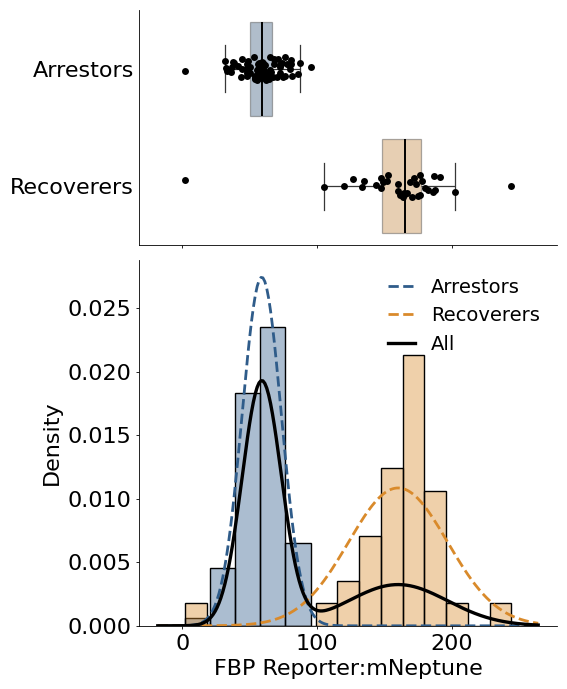

In [17]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Fit Gaussians ----------------
mu_arr, std_arr = stats.norm.fit(arr_vals)
mu_rec, std_rec = stats.norm.fit(rec_vals)

w_arr = len(arr_vals) / (len(arr_vals) + len(rec_vals))
w_rec = 1 - w_arr

x = np.linspace(min(arr_vals.min(), rec_vals.min()) - 20,
                max(arr_vals.max(), rec_vals.max()) + 20, 200)

pdf_arr = stats.norm.pdf(x, mu_arr, std_arr)
pdf_rec = stats.norm.pdf(x, mu_rec, std_rec)
pdf_mix = w_arr * pdf_arr + w_rec * pdf_rec

# ---------------- Aesthetics ----------------
plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 0.6

arr_color  = "#2F5C8A"   # denim
rec_color  = "#D98A2B"   # amber
fill_alpha = 0.4         # one alpha for every fill: both groups, box + histogram

# ---------------- Data frame ----------------
df_long = pd.DataFrame({
    "sfGFPmt": np.concatenate([arr_vals, rec_vals]),
    "State": (["Arrestors"] * len(arr_vals)) + (["Recoverers"] * len(rec_vals)),
})

bins_arr = np.histogram_bin_edges(arr_vals, bins=5)
bins_rec = np.histogram_bin_edges(rec_vals, bins=15)

# ---------------- Figure ----------------
fig = plt.figure(figsize=(5.4, 8.0), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[0.9, 1.4], hspace=0.05)

# Top: box + strip
ax_box = fig.add_subplot(gs[0, 0])
sns.boxplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, showfliers=False,
    palette=[arr_color, rec_color],
    linewidth=0.9,
    boxprops=dict(alpha=fill_alpha),
    medianprops=dict(color="k", linewidth=1.4),
)
sns.stripplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, color="k", size=5, alpha=1
)
ax_box.set_xlabel("")
ax_box.set_ylabel("")
ax_box.tick_params(axis="x", labelbottom=False, length=2, width=0.6)
ax_box.tick_params(axis="y", length=0, width=0.6)

# Bottom: hist + PDFs + mixture
ax_dist = fig.add_subplot(gs[1, 0], sharex=ax_box)

sns.histplot(
    arr_vals, bins=bins_arr, stat="density",
    color=arr_color, alpha=fill_alpha, edgecolor="k", ax=ax_dist
)
sns.histplot(
    rec_vals, bins=bins_rec, stat="density",
    color=rec_color, alpha=fill_alpha, edgecolor="k", ax=ax_dist
)

ax_dist.plot(x, pdf_arr, "--", linewidth=2, color=arr_color, label="Arrestors")
ax_dist.plot(x, pdf_rec, "--", linewidth=2, color=rec_color, label="Recoverers")
ax_dist.plot(x, pdf_mix, "-",  linewidth=2.4, color="k",        label="All")

ax_dist.set_xlabel(r"FBP Reporter:mNeptune")
ax_dist.set_ylabel("Density")
ax_dist.tick_params(length=2, width=0.6)
ax_dist.legend(frameon=False, fontsize=14, handlelength=1.4, loc='best')

sns.despine(fig)
plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']  # exists on Mac, Illustrator knows it

# High-res, vector-friendly save (adjust path as needed)
# fig.savefig(save_directory + "mtsfGFP_box_hist_mixture.pdf")
fig.savefig("Figure3_mtsfGFP_distribution.svg", format="svg")